# LSTM Training Notebook
**Phase 2 — F1 Deep Learning Project**

This notebook trains an LSTM model to predict F1 lap times using sequences of past laps.

In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import joblib
import sys
sys.path.append('..')
from models.lstm_model import LapTimeLSTM
print('All imports done!')

All imports done!


In [2]:
# Cell 2 — Load Data
df = pd.read_csv('../f1.csv', index_col=0, low_memory=False)

# Define features here so we can use them for cleaning
features = [
    'lap',
    'position',
    'pit_stop',
    'tyre_age',
    'grid',
    'alt',
    'race_year',
    'round'
]

# Replace '\N' strings with NaN globally
df = df.replace('\\N', np.nan)

# Ensure feature columns and target are numeric
numeric_cols = features + ['lap_time_ms']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing values in these columns
df = df.dropna(subset=numeric_cols)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (371427, 19)
Columns: ['raceId', 'driverId', 'lap', 'position', 'lap_time_ms', 'race_year', 'round', 'circuitId', 'race_name', 'race_date', 'race_time', 'pit_stop', 'tyre_age', 'constructorId', 'grid', 'positionOrder', 'lat', 'lng', 'alt']


In [3]:
# Cell 3 — Create Sequences
SEQ_LEN = 5

def create_sequences(group, seq_len=5):
    X, y = [], []
    vals   = group[features].values
    target = group['lap_time_ms'].values
    for i in range(len(vals) - seq_len):
        X.append(vals[i : i+seq_len])
        y.append(target[i+seq_len])
    return np.array(X), np.array(y)

X_list, y_list = [], []
for (race, driver), grp in df.groupby(['raceId','driverId']):
    grp = grp.sort_values('lap')
    if len(grp) > SEQ_LEN:
        X, y = create_sequences(grp)
        X_list.append(X)
        y_list.append(y)

X_all = np.concatenate(X_list)   # (total_samples, SEQ_LEN, len(features))
y_all = np.concatenate(y_list)   # (total_samples,)
print(f"Total sequences: {len(X_all)}")

Total sequences: 338039


In [4]:
# Cell 4 — Scale and Split
scaler = StandardScaler()

# Flatten time dimension, scale, then reshape back
X_flat   = X_all.reshape(-1, len(features))
X_scaled = scaler.fit_transform(X_flat).reshape(-1, SEQ_LEN, len(features))

joblib.dump(scaler, '../dl_scaler.pkl')
print('Scaler saved!')

split    = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_all[:split],    y_all[split:]

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test)

train_dl = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Scaler saved!
Train: 270431 | Test: 67608


In [5]:
# Cell 5 — Train LSTM
model     = LapTimeLSTM(input_size=len(features), hidden_size=128, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
loss_fn   = nn.MSELoss()

train_losses = []
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_dl:
        pred  = model(X_batch)
        loss  = loss_fn(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_dl)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.2f}")

torch.save(model.state_dict(), '../lstm_model.pth')
print("LSTM model saved!")

Epoch 1/30 | Loss: 13698916884.26
Epoch 2/30 | Loss: 7882188167.77
Epoch 3/30 | Loss: 7748127240.38
Epoch 4/30 | Loss: 7645234988.64
Epoch 5/30 | Loss: 7554831798.59
Epoch 6/30 | Loss: 7496825475.84
Epoch 7/30 | Loss: 7394948696.83
Epoch 8/30 | Loss: 7317150055.44
Epoch 9/30 | Loss: 7209653976.80
Epoch 10/30 | Loss: 7162761298.75
Epoch 11/30 | Loss: 7060209520.54
Epoch 12/30 | Loss: 7007521021.16
Epoch 13/30 | Loss: 6930658216.50
Epoch 14/30 | Loss: 6918432972.70
Epoch 15/30 | Loss: 6883866791.05
Epoch 16/30 | Loss: 6876479027.48
Epoch 17/30 | Loss: 6812809839.12
Epoch 18/30 | Loss: 6807491016.65
Epoch 19/30 | Loss: 6781085620.05
Epoch 20/30 | Loss: 6781905160.14
Epoch 21/30 | Loss: 6680018434.12
Epoch 22/30 | Loss: 6704113781.17
Epoch 23/30 | Loss: 6704790159.27
Epoch 24/30 | Loss: 6685873157.17
Epoch 25/30 | Loss: 6630763193.29
Epoch 26/30 | Loss: 6623768775.05
Epoch 27/30 | Loss: 6578125090.63
Epoch 28/30 | Loss: 6582910351.79
Epoch 29/30 | Loss: 6577822413.40
Epoch 30/30 | Loss: 65

In [6]:
# Cell 6 — Evaluate
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).numpy()

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred) / 1000  # convert ms → seconds

print(f"LSTM R2  : {r2:.4f}")
print(f"LSTM MAE : {mae:.3f} seconds")

LSTM R2  : -0.6324
LSTM MAE : 12.287 seconds


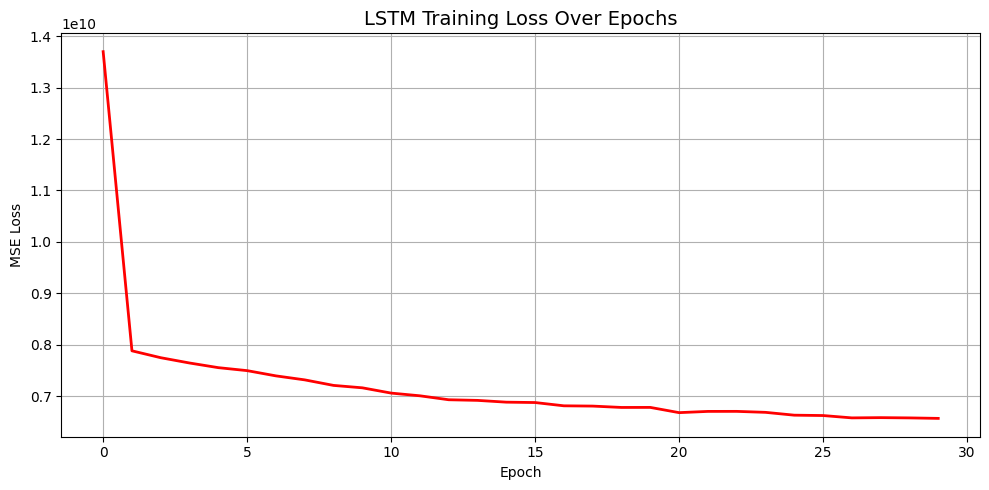

Plot saved!


In [7]:
# Cell 7 — Plot Training Loss
plt.figure(figsize=(10,5))
plt.plot(train_losses, color='red', linewidth=2)
plt.title('LSTM Training Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('../lstm_training_loss.png')
plt.show()
print('Plot saved!')